In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df_raw = pd.read_csv('mecaniqa_dataset.csv', parse_dates=['Data'])
df_raw = df_raw.sort_values('Data').set_index('Data')

In [3]:
full_range = pd.date_range(df_raw.index.min(), df_raw.index.max(), freq='D')
df = df_raw.reindex(full_range)
df.index.name = 'Data'

In [4]:
df_com_outliers = df.copy()

In [5]:
df['Trocas_Oleo'] = df['Trocas_Oleo'].interpolate(method='time')
df['Manutencao_Motor'] = df['Manutencao_Motor'].interpolate(method='time')

In [6]:
df.loc[df['Trocas_Oleo'] < 0, 'Trocas_Oleo'] = np.nan
df.loc[df['Manutencao_Motor'] < 0, 'Manutencao_Motor'] = np.nan
df['Trocas_Oleo'] = df['Trocas_Oleo'].interpolate(method='time')
df['Manutencao_Motor'] = df['Manutencao_Motor'].interpolate(method='time')

In [7]:
def detectar_outliers_zscore(serie, limiar=3):
    z = (serie - serie.mean()) / serie.std()
    return z.abs() > limiar

outliers_oleo = detectar_outliers_zscore(df['Trocas_Oleo'])
outliers_motor = detectar_outliers_zscore(df['Manutencao_Motor'])

df.loc[outliers_oleo, 'Trocas_Oleo'] = np.nan
df.loc[outliers_motor, 'Manutencao_Motor'] = np.nan
df['Trocas_Oleo'] = df['Trocas_Oleo'].interpolate(method='time')
df['Manutencao_Motor'] = df['Manutencao_Motor'].interpolate(method='time')

print("Limpeza concluída. Dataset final:", df.shape)

Limpeza concluída. Dataset final: (731, 2)


In [8]:
NAVY = "#1B1F3B"
GREEN = "#8CC63F"
GRAY = "#B0B3B8"
RED = "#D64550"

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = '-'

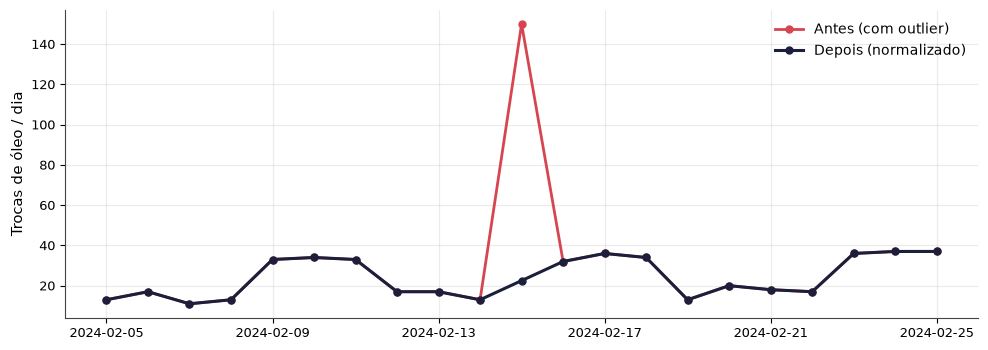

In [ ]:
# Tratamento de Outliers

fig, ax = plt.subplots(figsize=(10, 3.6))
janela = slice('2024-02-05', '2024-02-25')

ax.plot(df_com_outliers.loc[janela].index, df_com_outliers.loc[janela, 'Trocas_Oleo'],
        'o-', color=RED, linewidth=2, markersize=5, label='Antes (com outlier)')
ax.plot(df.loc[janela].index, df.loc[janela, 'Trocas_Oleo'],
        'o-', color=NAVY, linewidth=2.2, markersize=5, label='Depois (normalizado)')

ax.set_ylabel('Trocas de óleo / dia', fontsize=11)
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

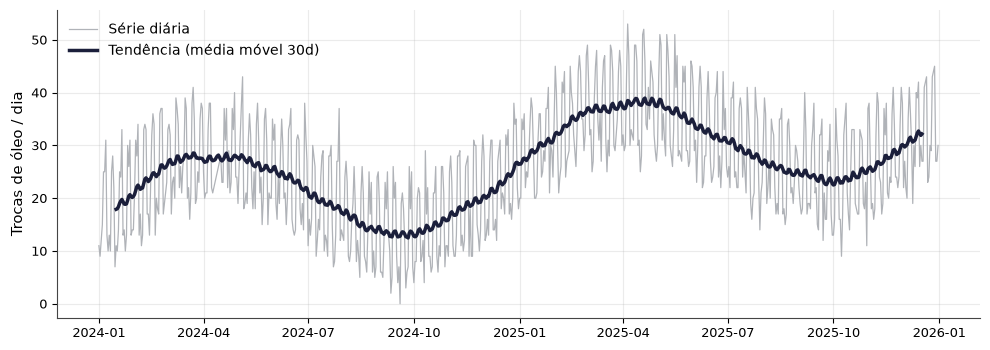

In [ ]:
# Série Temporal Completa + Tendência (média móvel 30 dias)
fig, ax = plt.subplots(figsize=(10, 3.6))

mm30 = df['Trocas_Oleo'].rolling(30, center=True).mean()
ax.plot(df.index, df['Trocas_Oleo'], color=GRAY, linewidth=0.9, label='Série diária')
ax.plot(df.index, mm30, color=NAVY, linewidth=2.5, label='Tendência (média móvel 30d)')

ax.set_ylabel('Trocas de óleo / dia', fontsize=11)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

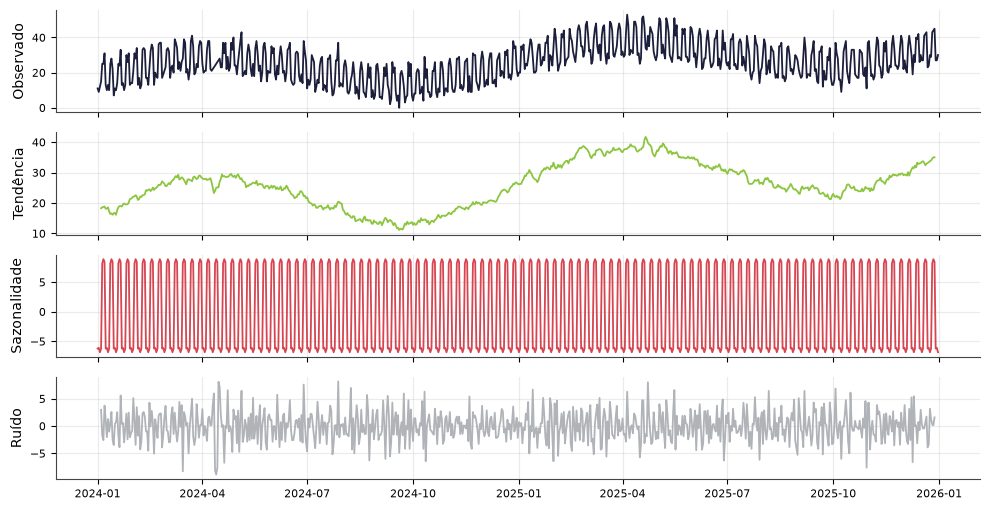

In [ ]:
# Decomposição (Observado, Tendência, Sazonalidade, Ruído)

dec = seasonal_decompose(df['Trocas_Oleo'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(10, 5.2), sharex=True)
componentes = [
    (dec.observed, 'Observado', NAVY),
    (dec.trend, 'Tendência', GREEN),
    (dec.seasonal, 'Sazonalidade', RED),
    (dec.resid, 'Ruído', GRAY),
]
for eixo, (serie, rotulo, cor) in zip(axes, componentes):
    eixo.plot(serie.index, serie, color=cor, linewidth=1.3)
    eixo.set_ylabel(rotulo, fontsize=10)
    eixo.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

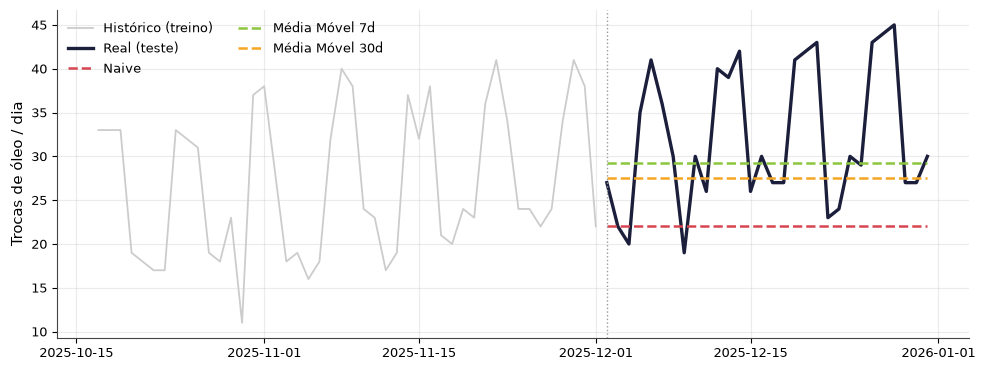

In [ ]:
#Real x Previsões Baseline (Naive, MM7, MM30)

corte = df.index.max() - pd.Timedelta(days=30)
treino = df.loc[:corte]
teste = df.loc[corte + pd.Timedelta(days=1):]

def previsao_naive(serie, horizonte):
    ultimo_valor = serie.iloc[-1]
    datas_futuras = pd.date_range(serie.index[-1] + pd.Timedelta(days=1), periods=horizonte, freq='D')
    return pd.Series([ultimo_valor] * horizonte, index=datas_futuras)

def previsao_media_movel(serie, janela, horizonte):
    media = serie.iloc[-janela:].mean()
    datas_futuras = pd.date_range(serie.index[-1] + pd.Timedelta(days=1), periods=horizonte, freq='D')
    return pd.Series([media] * horizonte, index=datas_futuras)

pred_naive = previsao_naive(treino['Trocas_Oleo'], horizonte=len(teste))
pred_mm7 = previsao_media_movel(treino['Trocas_Oleo'], janela=7, horizonte=len(teste))
pred_mm30 = previsao_media_movel(treino['Trocas_Oleo'], janela=30, horizonte=len(teste))

fig, ax = plt.subplots(figsize=(10, 3.8))
janela_plot = treino.loc[treino.index.max() - pd.Timedelta(days=45):]

ax.plot(janela_plot.index, janela_plot['Trocas_Oleo'], color='#CCCCCC', linewidth=1.3, label='Histórico (treino)')
ax.plot(teste.index, teste['Trocas_Oleo'], color=NAVY, linewidth=2.4, label='Real (teste)')
ax.plot(pred_naive.index, pred_naive, '--', color=RED, linewidth=1.8, label='Naive')
ax.plot(pred_mm7.index, pred_mm7, '--', color=GREEN, linewidth=1.8, label='Média Móvel 7d')
ax.plot(pred_mm30.index, pred_mm30, '--', color='#F5A623', linewidth=1.8, label='Média Móvel 30d')
ax.axvline(teste.index.min(), color='#999999', linestyle=':', linewidth=1)

ax.set_ylabel('Trocas de óleo / dia', fontsize=11)
ax.legend(frameon=False, fontsize=9, loc='upper left', ncol=2)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Avaliação (MAE / RMSE)

def mae(real, previsto):
    return np.mean(np.abs(real - previsto))

def rmse(real, previsto):
    return np.sqrt(np.mean((real - previsto) ** 2))

print("\nAvaliação dos baselines (últimos 30 dias, Trocas_Oleo):")
for nome, pred in [('Naive', pred_naive), ('Média Móvel 7d', pred_mm7), ('Média Móvel 30d', pred_mm30)]:
    print(f"  {nome:<18} MAE={mae(teste['Trocas_Oleo'], pred):.2f}  RMSE={rmse(teste['Trocas_Oleo'], pred):.2f}")


Avaliação dos baselines (últimos 30 dias, Trocas_Oleo):
  Naive              MAE=10.50  RMSE=12.83
  Média Móvel 7d     MAE=6.66  RMSE=8.34
  Média Móvel 30d    MAE=6.99  RMSE=9.08
